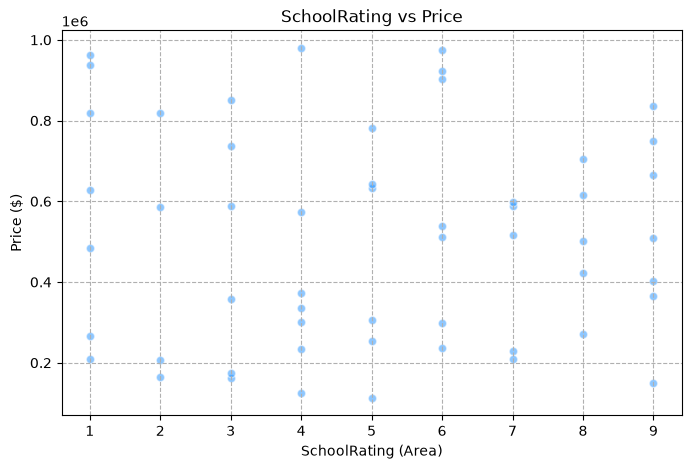

In [1]:
# 2강 1장 1-1
# 1. 필요 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 1. 파일 불러오기
df = pd.read_csv('usa_housing.csv')

# 2. 데이터 필터링하여 새로운 데이터프레임 만들기
df = df[(df['YearBuilt'] > 2000)]

# 3. 산점도 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(df['SchoolRating'], df['Price'], color='dodgerblue', alpha=0.5, edgecolor='w')
plt.title('SchoolRating vs Price')
plt.xlabel('SchoolRating (Area)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--')
plt.show()

In [2]:
# 2강 1장 2-1
# 1. 사이킷런 라이브러리에서 모델 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error     # mean_squared_error: MSE(평균 제곱 오차), mean_absolute_error: MAE(평균 절대 오차)
import sklearn
sklearn.set_config(display="text")

# 2. 필터링한 데이터프레임 특성과 레이블 지정하기
X = df[['SchoolRating']].values
y = df['Price'].values

X.shape, y.shape

# 3. 모델 학습 진행하기
model = LinearRegression()
model.fit(X, y)

# 4. 가중치와 편향 값 확인하기
print(model.coef_, model.intercept_)

[-2216.81807051] 517149.0499464313


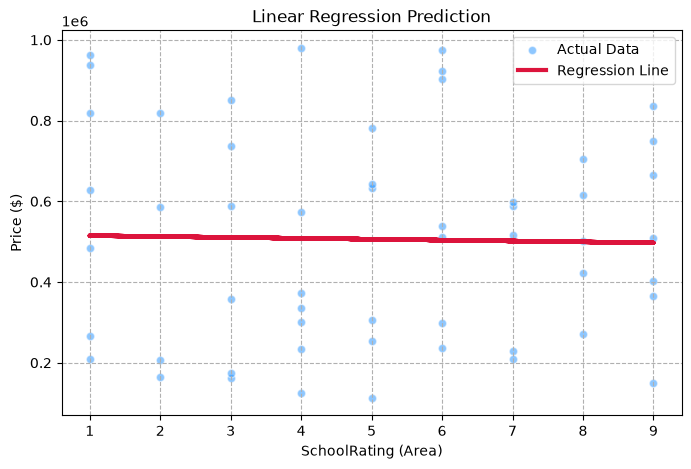

MSE: 66847213624.739105
MAE: 222660.70667407376


In [3]:
# 2강 1장 3-1
# 1. 학습 완료된 모델 예측값 생성하기
y_pred = model.predict(X)
y_pred

# 2. 산점도 그래프 위에 예측값 직선 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.5, edgecolor='w', label='Actual Data')
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Regression Line')
plt.title('Linear Regression Prediction')
plt.xlabel('SchoolRating (Area)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# 3. 평균 제곱 오차와 평균 절대 오차 계산하여 출력하기
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("MSE:", mse)
print("MAE:", mae)

In [4]:
# 2강 2장 1-1 가족형 주택 기준 데이터 분할하기
# 1. 필요 라이브러리 및 데이터 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('usa_housing.csv')
df.head()

# 2. 데이터 필터링하기
df = df[(df['Bedrooms'] >= 3)]
df.head()

# 3. 데이터 2차원 배열 형태로 추출하기
X = df[['CrimeRate']]
y = df['Price']

X.shape, y.shape

# 4. train_test_split 함수로 데이터 쪼개기
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42 
)

# 5. 분할된 데이터 세트 출력하기
print(f"전체 주택 데이터 수: {len(X)}채")
print(f"훈련용 주택: {len(X_train)}채")
print(f"검증용 주택: {len(X_valid)}채")
print(f"테스트용 주택: {len(X_test)}채")


전체 주택 데이터 수: 174채
훈련용 주택: 104채
검증용 주택: 35채
테스트용 주택: 35채


In [5]:
# 2강 2장 2-1 데이터 표준화 스케일링 적용하기
# 1. 필요 라이브러리 및 데이터 불러오기
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 2. 데이터 스케일링하기
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 3. fit_transform() 함수를 사용하여 분할한 데이터들을 표준 점수로 변환하기
X_scaler = scaler_X.fit_transform(X)

# 4. 변환된 데이터 1차원 배열로 변환하기
X_scaled = X_scaler.flatten()

# 5. 변환된 데이터 출력하기
print("전체 크기:", X_scaled.shape)

전체 크기: (174,)


In [6]:
# 2강 2장 3-1 학습률 설정 및 오차 기록 리스트 생성하기
# 1. 가중치와 편향 초기화하기
weight = 0.0
bias = 0.0

# 2. 학습률 0.05로 설정 후, 학습 진행하기
learning_rate = 0.05

# 3. 학습 횟수 에포크로 150회 지정하기
epochs = 150

# 4. 손실 변화 리스트 생성하기
train_losses = []
valid_losses = []

# 5. 학습 진행도 출력하기
print(weight, bias, train_losses, valid_losses)

0.0 0.0 [] []


In [7]:
# 3강 1장 1-1 독립 변수 다변화 및 기초 회귀 모델 정의
# 1. 필요 라이브러리 및 데이터 불러오기
import pandas as pd
from sklearn.linear_model import Ridge

df = pd.read_csv("student-por.csv")
df.head()

# 2. 독립 변수 X 데이터에 세가지(failures, goout, health) 컬럼 지정하기
X = df[['failures', 'goout', 'health']]

# 3. 종속 변수 y 데이터에 컬럼(G3) 지정하기
y = df['G3']
df.head()

# 4. 규제 강도 alpha 파라미터를 0으로 설정한 Ridge 모델 생성하고 학습 후, 가중치와 절편 출력하기
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

ridge = Ridge(alpha=0)
ridge.fit(X_scaled, y)
print(ridge.coef_, ridge.intercept_)

[-1.2493724  -0.23098036 -0.27828121] 11.906009244992296


In [8]:
# 3강 1장 2-1 고차원 파생 변수 생성 및 StandardScaler 활용
# 1. 


# 2. 


# 3. 


# 4. 


# 5. 

from sklearn.preprocessing import StandardScaler, PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

features_name = poly.get_feature_names_out(X.columns)
features_name

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.37430512,  0.69378496, -0.3710422 ],
       [-0.37430512, -0.15738033, -0.3710422 ],
       [-0.37430512, -1.00854562, -0.3710422 ],
       [-0.37430512, -1.00854562,  1.01290255],
       [-0.37430512, -1.00854562,  1.01290255]])

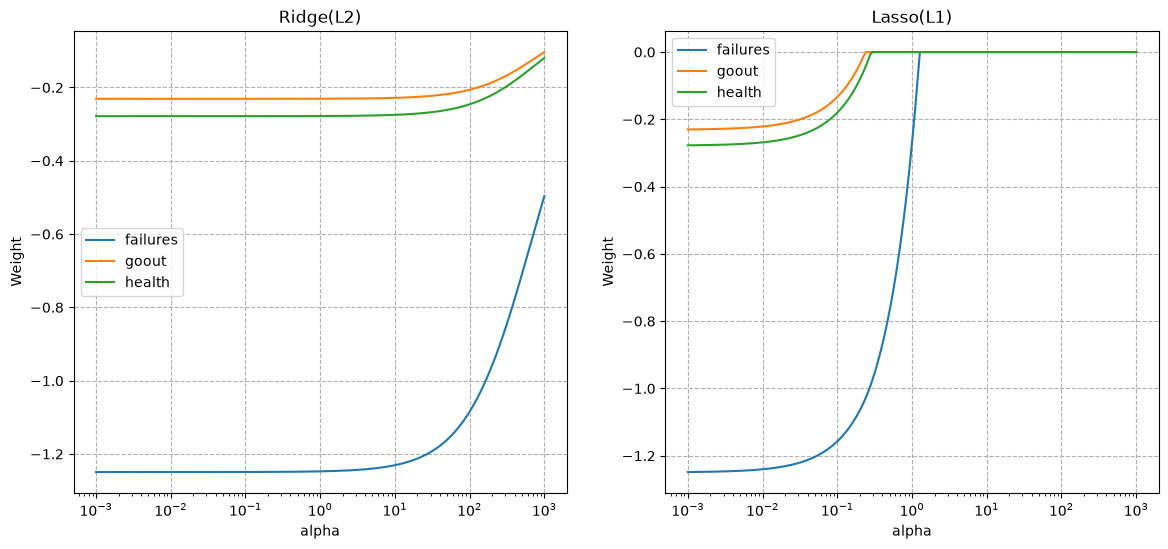

In [9]:
# 3강 1장 3-1 하이퍼파라미터 alpha 변화에 따른 계수 축소 시각화
# 1. 필요 라이브러리 및 데이터 불러오기
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# 1. logspace 함수를 사용하여 규제 강도 alpha 값 구성하기
alphas = np.logspace(-3, 3, 200)

# 2. 생성된 alpha 배열에 Ridge, Lasso 모델 각각 생성하여 전처리한 데이터 학습시키기
ridge_coefs = []
lasso_coefs = []

# 3. Lasso 모델의 최대 반복 횟수를 20000, 수렴 허용 오차를 1e-4로 설정하기
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=a, max_iter=20000, tol=1e-4)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

# 4. matplotlib를 사용하여 1행 2열 크기의 그래프 영역을 생성하고, 왼쪽은 Ridge, 오른쪽은 Lasso 모델을 시각화하기
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(X_scaled.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i], label=features_name[i])

axes[0].set_xscale('log')
axes[0].set_title('Ridge(L2)')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Weight')
axes[0].grid(True, linestyle='--')
axes[0].legend()

for i in range(X_scaled.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i], label=features_name[i])

axes[1].set_xscale('log')
axes[1].set_title('Lasso(L1)')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Weight')
axes[1].grid(True, linestyle='--')
axes[1].legend()

In [10]:
# 3강 2장 1-1 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")
df.head()

df_binary = df[df['Species'].isin(['Iris-versicolor', 'Iris-virginica'])].copy()

X_binary = df_binary[['SepalLengthCm', 'SepalWidthCm']]

y_binary = df_binary['Species'].map({'Iris-versicolor': 0, 'Iris-virginica': 1})

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
binary_model = LogisticRegression()
binary_model.fit(X_bin_train, y_bin_train)

bin_test_preds = binary_model.predict(X_bin_test)
bin_accuracy = accuracy_score(y_bin_test, bin_test_preds)
print(f"정확도: {bin_accuracy:.4f}")

정확도: 0.7000


In [11]:
# 3강 2장 2-1 
y_binary = df_binary['Species']

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

kf = KFold(shuffle=True, random_state=42)

multi_model = LogisticRegression()
multi_model.fit(X_multi_train, y_multi_train);

cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train, cv=kf)
print("평균 검증 정확도", cv_scores.mean())

multi_test_preds = multi_model.predict(X_multi_test)
multi_accuracy = accuracy_score(y_multi_test, multi_test_preds)

print(f"최종 테스트 정확도: {multi_accuracy:.4f}")

평균 검증 정확도 0.6875
최종 테스트 정확도: 0.7000


In [ ]:
# 3강 2장 3-1
X_binary = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y_binary = df['Species']

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

multi_model = LogisticRegression(max_iter=1000)
multi_model.fit(X_multi_train, y_multi_train)

cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train)
print(f"최종 테스트 정확도 수치: {cv_scores.mean():.4f}")

변수 네 개 정확도: 0.9667


In [37]:
X_binary = df[['SepalLengthCm', 'SepalWidthCm']]
y_binary = df['Species']

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

multi_model = LogisticRegression()
multi_model.fit(X_multi_train, y_multi_train)

cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train)
print(f"정확도: {cv_scores.mean():.4f}")

정확도: 0.8500
